In [1]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.qasm3 import dumps, loads
from ConstantPropagation import ConstantPropagation
from qiskit.circuit.classical import expr

## Test cases

In [3]:
def one_mid_meas_pure_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc

def one_mid_meas_mixed_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.cx(qr[0], cr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc


def reset_pure_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])
    qc.reset(qr[0])
    qc.x(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc

def mid_meas_whole_reg_true():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.x(qr[0])
    qc.x(qr[1])

    qc.measure(qr, cr) # cr = 3
    with qc.if_test((cr, 4)):
        qc.z(qr[2])

    return qc

def mid_meas_whole_reg_false():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)


    qc.x(qr[0])
    qc.x(qr[2])

    qc.measure(qr, cr)
    with qc.if_test((cr, 3)):
        qc.z(qr[2])

    return qc

def create_constant_depth_ghz(n_qubits: int) -> QuantumCircuit:
    """
    Create a constant-depth circuit for GHZ state preparation using the pattern:
    - H gates on even qubits (0,2,...)
    - CNOTs from even qubits to their neighbors
    - Measurements on odd qubits
    - Conditional operations based on measurements
    
    Args:
        n_qubits: Number of qubits in the GHZ state
    Returns:
        QuantumCircuit: Circuit that prepares the GHZ state
    """
    qr = QuantumRegister(n_qubits, 'q')
    cr1 = ClassicalRegister((n_qubits-1)//2, 'cr1')  # We need classical bits for odd qubits
    qc = QuantumCircuit(qr, cr1)
    
    # First layer: Apply H gates to even-numbered qubits
    for i in range(0, n_qubits, 2):
        qc.h(i)
    
    # Second layer: Apply CNOTs from even qubits to neighbors
    for i in range(0, n_qubits-1, 2):
        # CNOT to next qubit
        qc.cx(i, i+1)
        # CNOT to previous qubit if it exists and isn't the first qubit
        if i > 0:
            qc.cx(i, i-1)
 
    qc.cx(-1, -2)  # Last CNOT to ensure the last qubit is entangled

    # Third layer: Measure odd-numbered qubits
    for i in range(1, n_qubits, 2):
        qc.measure(i, cr1[i//2])

    # Fourth layer: Conditional operations with XOR patterns
    # First condition is simple measurement check
    with qc.if_test((cr1[0], 1)):
        qc.x(2)

    # Subsequent conditions use XOR of increasing measurements
    for i in range(3, n_qubits-1, 2):
        xor_expr = expr.lift(cr1[0])
        # XOR with subsequent measurements
        for j in range(1, i//2 + 1):
            xor_expr = expr.bit_xor(cr1[j], xor_expr)
        with qc.if_test((xor_expr)):
            qc.x(i+1)

    # Fifth layer: Reset measured qubits
    for i in range(1, n_qubits, 2):
        qc.reset(i)
    
    # Sixth layer: CNOTs between reset qubits
    for i in range(0, n_qubits-1, 2):
        qc.cx(i, i+1)

    qc.measure_all()
 
    return qc

## Initial circuit

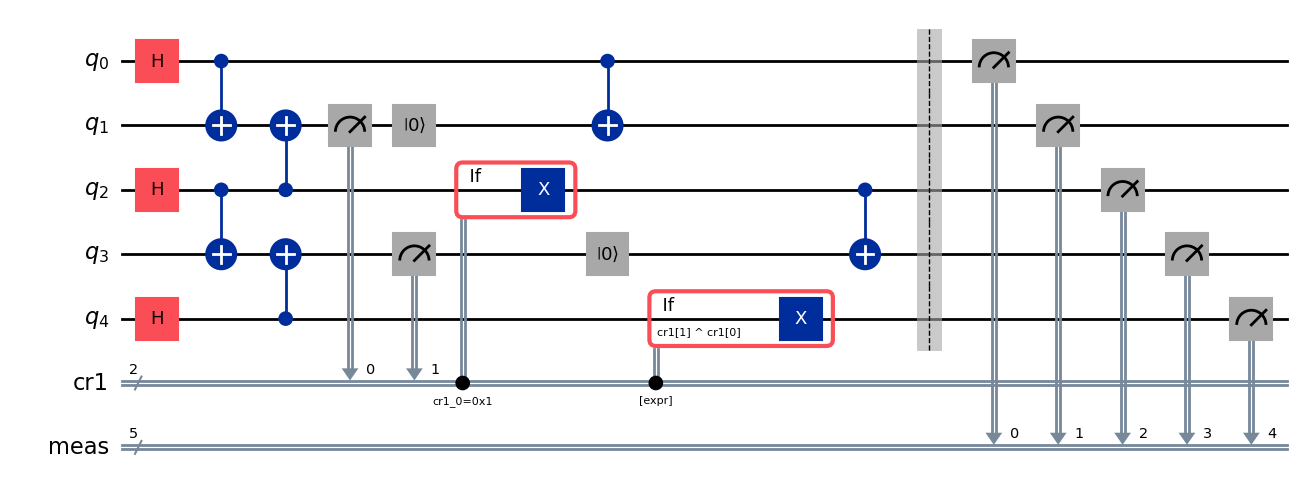

In [4]:
qc = create_constant_depth_ghz(5)
qc.draw('mpl')

## Optimised circuit

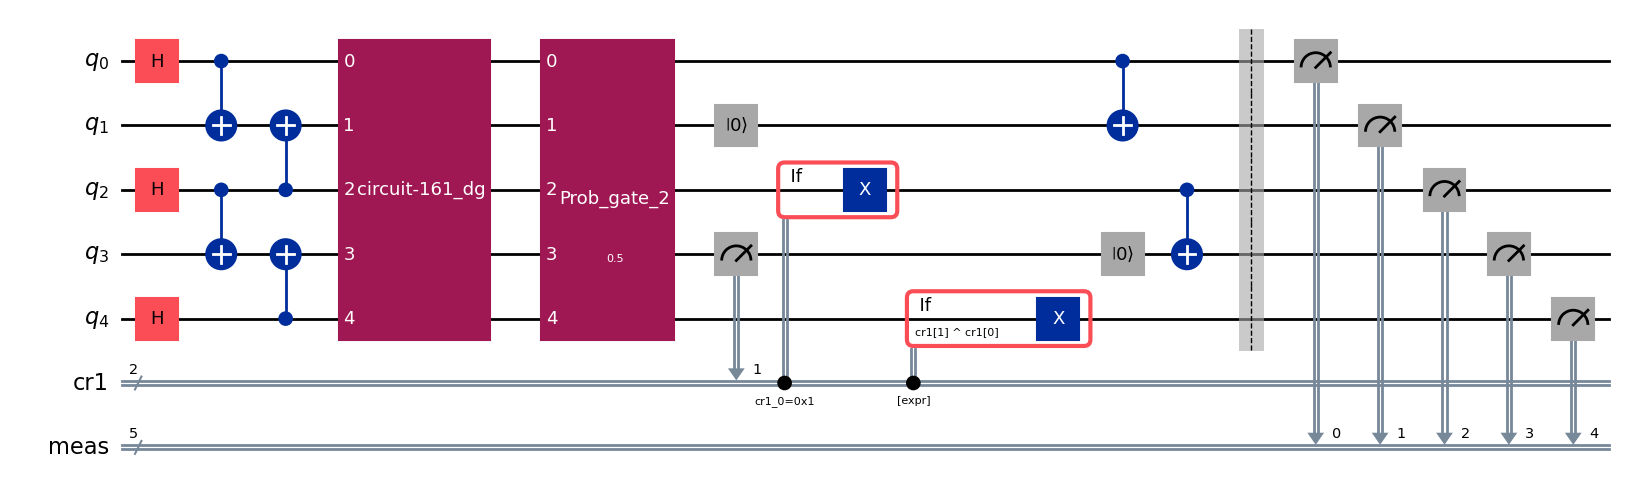

In [5]:
table, qc_opt = ConstantPropagation.optimize(qc, max_ent_group_size=10)
qc_opt.draw('mpl')


In [5]:

for instr in qc_opt.data:
    print(instr)

CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(5, 'q'), 0),), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(5, 'q'), 2),), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(5, 'q'), 4),), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(5, 'q'), 0), Qubit(QuantumRegister(5, 'q'), 1)), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(5, 'q'), 2), Qubit(QuantumRegister(5, 'q'), 3)), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(5, 'q'), 2), Qubit(QuantumRegister(5, 'q'), 1)), clbits=())
CircuitInstru

## Instance

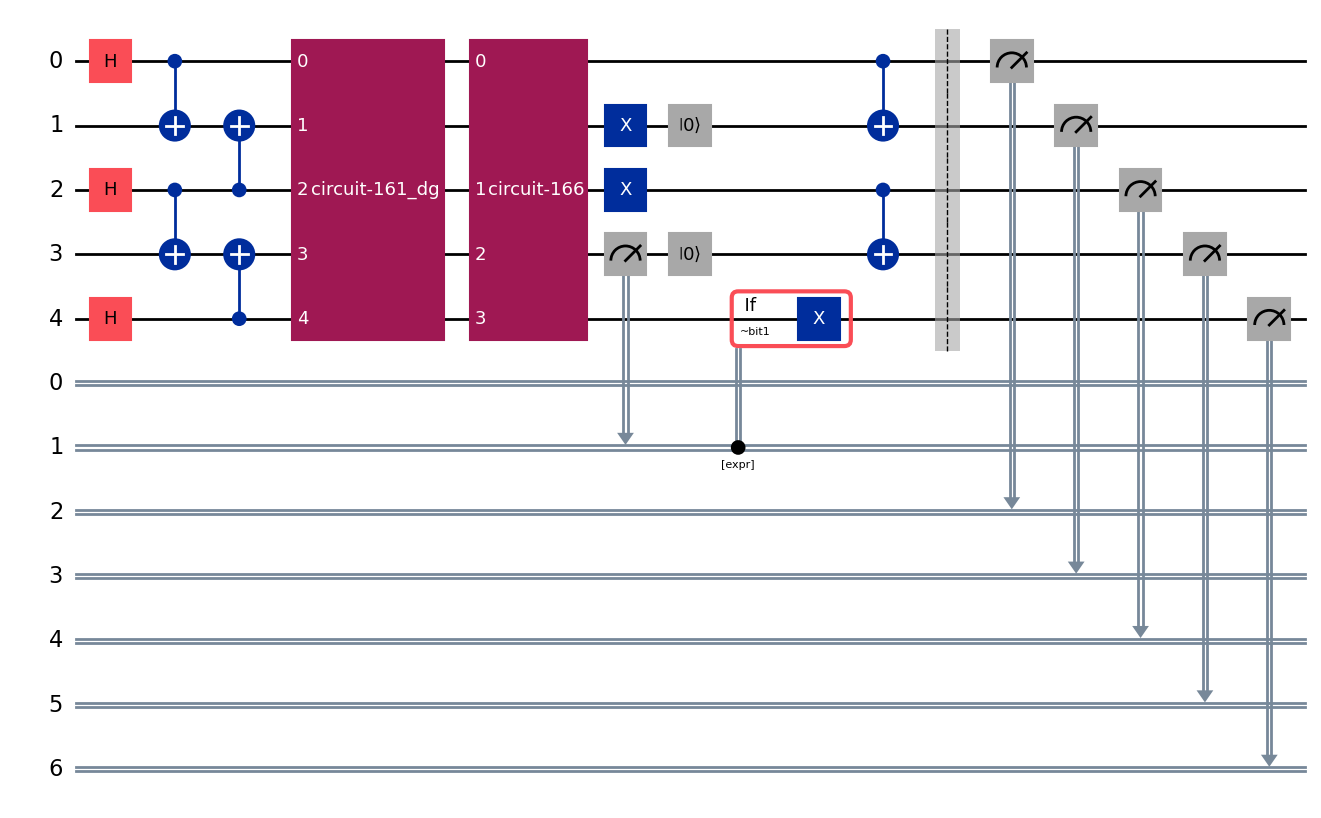

In [6]:
instance = ConstantPropagation.generate_instance(qc_opt)
instance.draw('mpl')

## RANDOM CIRCUITS

In [2]:
from util.MyRandomCircuit import my_random_circuit

circ, info = my_random_circuit(25, depth=20, conditional=True, reset=True, max_operands=2, ccop_density=0.1)
print(info)
# circ.draw('mpl')

[598, 46]


In [30]:
for instr in circ.data:
    if instr.operation.name == 'if_else':
        print(instr.operation.condition)

Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_OR, Binary(Binary.Op.BIT_OR, Binary(Binary.Op.BIT_OR, Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_OR, Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_OR, Binary(Binary.Op.BIT_XOR, Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_OR, Var(Clbit(ClassicalRegister(25, 'c'), 3), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 19), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 17), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 16), Bool()), Bool()), Unary(Unary.Op.BIT_NOT, Var(Clbit(ClassicalRegister(25, 'c'), 1), Bool()), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 14), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 12), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 10), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 0), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 4), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 

In [3]:
_, circ_opt, info_opt = ConstantPropagation.optimize(circ, max_ent_group_size=32, max_amplitudes=4096)
print(info_opt)
# circ_opt.draw('mpl')

[400, 39]


In [32]:
for instr in circ_opt.data:
    if instr.operation.name == 'if_else':
        print(instr.operation.condition)

Binary(Binary.Op.BIT_AND, Var(Clbit(ClassicalRegister(25, 'c'), 15), Bool()), Unary(Unary.Op.BIT_NOT, Var(Clbit(ClassicalRegister(25, 'c'), 22), Bool()), Bool()), Bool())
Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_OR, Binary(Binary.Op.BIT_AND, Binary(Binary.Op.BIT_OR, Binary(Binary.Op.BIT_AND, Var(Clbit(ClassicalRegister(25, 'c'), 12), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 10), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 17), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 22), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 13), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 18), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 5), Bool()), Bool()), Var(Clbit(ClassicalRegister(25, 'c'), 7), Bool()), Bool())
Unary(Unary.Op.BIT_NOT, Var(Clbit(ClassicalRegister(25, 'c'), 15), Bool()), Bool())
Var(Clbit(ClassicalRegister(25, 'c'), 11), Bool())
(Clbit(ClassicalRegister(25, 'c'), 18)

In [33]:
circ_instance = ConstantPropagation.generate_instance(circ_opt)
circ_instance.draw('mpl')